In [1]:
import requests
import json
import pandas as pd
import numpy as np
from tqdm import tqdm

##나의 key
key = 'bf388499b71a365d725e1c888201736f7409d7e4'

In [2]:
#### HS Code 를 확인한다

path = r"C:\Users\MetaM\PycharmProjects\stock_forecast\DATA\미국_200대_수출금액_.HScode_202506.xlsx"

hs_raw = pd.read_excel(path)

hs_raw['hs_code'] = hs_raw['HS_Code'].astype(str).str[:6]
# print(len(hs_code))

hs_code = hs_raw['hs_code'].unique().tolist()
hs_code = hs_code[:3]
hs_code

['880000', '270900', '710812']

In [3]:
start_year = '2016-03-01'
start_y = 2025
start_q = 1
export_import = 'expDlr'

# 월말 날짜 생성
dates_period = pd.date_range(start='2020-01', end='2025-05', freq='ME')


dates_list1 = []
for dates in dates_period:
    temp = str(dates)[:7]
    dates_list1.append(temp)


In [4]:
def get_us_export_data(hs_list, start='2013-01', end='2025-05', api_key='your_key_here'):
    """
    미국 HS 코드별 수출 데이터를 월별로 가져옵니다.

    Parameters:
        hs_list (list): 조회할 HS 코드 리스트
        start (str): 시작 날짜 (yyyy-mm)
        end (str): 종료 날짜 (yyyy-mm)
        api_key (str): U.S. Census API 키

    Returns:
        pd.DataFrame: 월별 수출 데이터
        pd.DataFrame: 분기별 수출 데이터
    """
    us_export_hs = []
    date_range = pd.date_range(start=start, end=end, freq='MS')  # 매월 시작일

    total_steps = len(hs_list) * len(date_range)
    with tqdm(total=total_steps, desc="미국 수출 데이터 다운로드 중") as pbar:
        for hs in hs_list:
            for dt in date_range:
                year = dt.strftime('%Y')
                month = dt.strftime('%m')
                url = (
                    f"https://api.census.gov/data/timeseries/intltrade/exports/hs"
                    f"?get=ALL_VAL_MO&key={api_key}&YEAR={year}&MONTH={month}&E_COMMODITY={hs}"
                )
                try:
                    res = requests.get(url)
                    if res.status_code == 200:
                        data = json.loads(res.text)
                        if len(data) > 1:
                            temp = data[1]
                            us_export_hs.append(temp)
                    else:
                        print(f"❌ 실패: {year}-{month} {hs} → Status: {res.status_code}")
                except Exception as e:
                    print(f"⚠️ 예외 발생: {year}-{month} {hs} → {e}")
                pbar.update(1)

    if not us_export_hs:
        print("❌ 가져온 데이터가 없습니다.")
        return None, None

    # 데이터프레임 생성 및 컬럼 설정
    df = pd.DataFrame(us_export_hs, columns=['expDlr', 'year', 'month', 'hs_code'])

    df['expDlr'] = pd.to_numeric(df['expDlr'], errors='coerce')
    df.loc[df['expDlr'] > 1e18, 'expDlr'] = np.nan

    df['date'] = pd.to_datetime(df['year'] + '-' + df['month'], errors='coerce') + pd.offsets.MonthEnd(0)
    df.dropna(subset=['date'], inplace=True)
    df.set_index('date', inplace=True)
    df['quarter'] = df.index.to_period('Q')

    df_monthly = df.copy()
    df_quarterly = df.groupby(['quarter', 'hs_code'])['expDlr'].sum().reset_index()
    df_quarterly['quarter'] = df_quarterly['quarter'].dt.to_timestamp()

    return df_monthly, df_quarterly

def upload_trade_data_to_db(df, db_info, table_name='us_trade_data'):
    """
    미국 월별 수출 데이터를 지정한 DB 테이블에 업로드합니다.

    Parameters:
        df (DataFrame): 업로드할 월별 수출 데이터프레임
        db_info (dict): DB 접속 정보 (user, password, host, port, database)
        table_name (str): 업로드할 테이블 이름
    """
    from sqlalchemy import create_engine

    engine = create_engine(
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}@"
        f"{db_info['host']}:{db_info['port']}/{db_info['database']}"
    )

    try:
        df_reset = df.reset_index()
        df_reset.to_sql(name=table_name, con=engine, if_exists='replace', index=False)
        print(f"✅ 데이터가 '{table_name}' 테이블에 성공적으로 업로드되었습니다.")
    except Exception as e:
        print(f"❌ DB 업로드 실패: {e}")


In [9]:
hs_code = ['854232']
us_export_month, us_export_quarter = get_us_export_data(
    hs_list= hs_code,
    start='2013-01',
    end='2025-05',
    api_key= key  # 실제 API 키로 바꾸세요
)

미국 수출 데이터 다운로드 중: 100%|██████████| 149/149 [02:23<00:00,  1.04it/s]


<Axes: xlabel='date'>

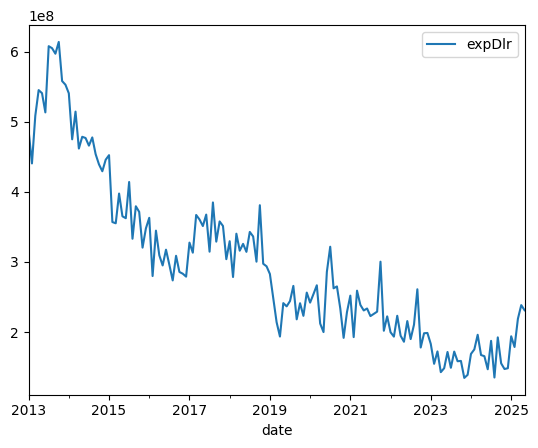

In [11]:
us_export_month[['expDlr']].plot()

In [15]:
db_info = {
    # 'host' : '192.168.0.230',
    'host' : 'hystox74.synology.me',
    'port' : 3307,
    'user' : 'stox7412',
    'password' : 'Apt106503!~',
    'database' : 'investar'
}

upload_trade_data_to_db(us_export_month, db_info)

✅ 데이터가 'us_trade_data' 테이블에 성공적으로 업로드되었습니다.
